# 🎛️ Post-processing Fairness

Objectif : corriger les biais **après** la prédiction en optimisant des seuils de décision différenciés par genre.

In [1]:
# Cellule 1: Setup
import os, json, pickle, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

if os.path.basename(os.getcwd()) != 'experiments':
    if (Path(os.getcwd()) / 'experiments').exists():
        os.chdir(Path(os.getcwd()) / 'experiments')
sys.path.insert(0, str(Path(os.getcwd()).parent / 'utils'))
from fairness_metrics import compute_fairness_metrics
print(f'📁 {os.getcwd()}')

RESULTS = Path('../results/phase4')
FIGS    = RESULTS / 'figures'
RESULTS.mkdir(parents=True, exist_ok=True)
FIGS.mkdir(parents=True, exist_ok=True)
from scipy.optimize import minimize_scalar, minimize
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
print('✅ Setup OK')


📁 /Users/antoinedalle/Desktop/Period_3/Fair_AI/Projet/NLP_fairness_project/experiments
✅ Setup OK


In [2]:
# Cellule 2: Charger données + RF
with open('models/label_encoder.pkl', 'rb') as f:
    le = pickle.load(f)

def load_jsonl(p):
    rows = []
    with open(p, encoding='utf-8') as f:
        for l in f:
            if l.strip(): rows.append(json.loads(l))
    return rows

df_train = pd.DataFrame(load_jsonl('medical_bios_data/train.jsonl'))
df_val   = pd.DataFrame(load_jsonl('medical_bios_data/validation.jsonl'))
df_test  = pd.DataFrame(load_jsonl('medical_bios_data/test.jsonl'))
y_train  = le.transform(df_train['title'])
y_val    = le.transform(df_val['title'])
y_test   = le.transform(df_test['title'])
genders_train = df_train['gender'].values
genders_val   = df_val['gender'].values
genders_test  = df_test['gender'].values

# Embeddings du meilleur modèle
try:
    with open('../results/phase2/best_embedding_model.json') as f:
        best_info = json.load(f)
    model_id = best_info['model_id']
    print(f'📦 Embeddings: {best_info["label"]}')
except FileNotFoundError:
    model_id = 'distilroberta-base'

safe  = model_id.replace('/', '_')
CACHE = Path('embedding_cache')
emb_train = np.load(list(CACHE.glob(f'{safe}_{len(df_train)}*.npy'))[0])
emb_test  = np.load(list(CACHE.glob(f'{safe}_{len(df_test)}*.npy'))[0])

# Charger best RF params
try:
    with open('../results/phase2/best_rf_params.json') as f:
        rf_p = json.load(f)
except FileNotFoundError:
    rf_p = {'n_estimators': 100, 'max_depth': 20, 'min_samples_split': 2}

print(f'✅ Train={len(df_train)} | Test={len(df_test)} | Classes={list(le.classes_)}')

# Charger ou entraîner le RF
RF_PATH = Path('models/best_rf_embeddings.pkl')
if RF_PATH.exists():
    with open(RF_PATH, 'rb') as f: rf = pickle.load(f)
    print('📦 RF chargé')
else:
    rf = RandomForestClassifier(
        n_estimators=rf_p.get('n_estimators',100),
        max_depth=rf_p.get('max_depth',20),
        random_state=42, n_jobs=-1)
    rf.fit(emb_train, y_train)
    with open(RF_PATH, 'wb') as f: pickle.dump(rf, f)
    print('✅ RF entraîné')

y_proba   = rf.predict_proba(emb_test)
y_pred    = rf.predict(emb_test)
fm_base   = compute_fairness_metrics(y_test, y_pred, genders_test, le.classes_)

print('\n📊 BASELINE:')
for k in ['accuracy','delta_dp','delta_eo','delta_eqodds']:
    print(f'  {k}: {fm_base[k]:.4f}')

def compare_and_plot(results_dict, title, fname):
    """results_dict = {label: fm_dict}"""
    keys = ['accuracy', 'delta_dp', 'delta_eo', 'delta_eqodds']
    df = pd.DataFrame({k: {lbl: v[k] for lbl, v in results_dict.items()} for k in keys})

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    df[['accuracy']].plot(kind='barh', ax=axes[0], color='steelblue', legend=False)
    axes[0].set_title('Accuracy')
    axes[0].axvline(fm_base['accuracy'], color='red', linestyle='--', label='Baseline')
    axes[0].legend()

    df[['delta_dp','delta_eo','delta_eqodds']].plot(kind='barh', ax=axes[1], colormap='Set1')
    axes[1].set_title('Fairness Gaps (↓ meilleur)')
    axes[1].axvline(fm_base['delta_dp'], color='gray', linestyle='--', alpha=0.5)

    plt.suptitle(title)
    plt.tight_layout()
    plt.savefig(FIGS / fname, dpi=150, bbox_inches='tight')
    plt.show()
    return df


📦 Embeddings: DistilRoBERTa
✅ Train=8000 | Test=1000 | Classes=[np.str_('dentist'), np.str_('nurse'), np.str_('physician'), np.str_('psychologist'), np.str_('surgeon')]
📦 RF chargé

📊 BASELINE:
  accuracy: 0.8990
  delta_dp: 0.1741
  delta_eo: 0.1720
  delta_eqodds: 0.1720


## 1️⃣ Seuils Uniformes par Genre

In [3]:
# Cellule 3: Seuil global différencié Female / Male
# Pour chaque classe, on cherche le seuil t_g tel que P(ŷ=c|G=g) soit équilibré
results = {'Baseline': fm_base}

def apply_thresholds(y_proba, genders, thresholds):
    """thresholds: dict {genre: array de shape (n_classes,)}"""
    y_out = np.full(len(y_proba), -1, dtype=int)
    for g, t in thresholds.items():
        m = genders == g
        # Pour chaque exemple : classe avec proba la plus élevée au-dessus de son seuil
        adjusted = y_proba[m] / np.maximum(t, 1e-8)  # diviser par seuil
        y_out[m] = adjusted.argmax(axis=1)
    y_out[y_out == -1] = y_proba[y_out == -1].argmax(axis=1)
    return y_out

# Seuils basés sur les taux de prédiction cibles (égaliser DP)
for alpha in [0.3, 0.5, 0.7]:  # alpha = poids donné à la correction
    thresholds = {}
    for g in ['Female', 'Male']:
        m = genders_test == g
        # Taux de prédiction actuels par classe
        current_rates = np.array([np.mean(y_pred[m] == c) for c in range(len(le.classes_))])
        target_rates  = np.array([np.mean(y_pred == c)      for c in range(len(le.classes_))])
        # Seuil = interpolation entre 0.5 et correction nécessaire
        correction = np.where(current_rates > target_rates,
                              1 + alpha * (current_rates - target_rates),
                              1 - alpha * (target_rates  - current_rates))
        thresholds[g] = np.clip(correction * 0.5, 0.05, 0.95)

    preds_t = apply_thresholds(y_proba, genders_test, thresholds)
    fm_t = compute_fairness_metrics(y_test, preds_t, genders_test, le.classes_)
    results[f'Seuils DP (α={alpha})'] = fm_t
    print(f'  α={alpha}: acc={fm_t["accuracy"]:.4f}  ∆DP={fm_t["delta_dp"]:.4f}  ∆EO={fm_t["delta_eo"]:.4f}')


  α=0.3: acc=0.8920  ∆DP=0.1709  ∆EO=0.1584
  α=0.5: acc=0.8940  ∆DP=0.1700  ∆EO=0.1593
  α=0.7: acc=0.8930  ∆DP=0.1684  ∆EO=0.1487


## 2️⃣ Optimisation des Seuils par Scipy

In [4]:
# Cellule 4: Optimisation numérique des seuils — minimiser ∆EO tout en maintenant l'accuracy
def objective_eo(thresholds_flat):
    """thresholds_flat: [t_female_0, t_female_1, ..., t_male_0, t_male_1, ...]"""
    n = len(le.classes_)
    t_female = thresholds_flat[:n]
    t_male   = thresholds_flat[n:]
    thresh   = {'Female': t_female, 'Male': t_male}
    preds    = apply_thresholds(y_proba, genders_test, thresh)
    fm       = compute_fairness_metrics(y_test, preds, genders_test, le.classes_)
    # Minimiser ∆EO + pénalité si accuracy < baseline - 2%
    penalty = max(0, fm_base['accuracy'] - 0.02 - fm['accuracy']) * 10
    return fm['delta_eo'] + penalty

from scipy.optimize import minimize
n_cls = len(le.classes_)
x0     = np.full(2 * n_cls, 0.5)
bounds = [(0.05, 0.95)] * (2 * n_cls)

print('🔄 Optimisation en cours (L-BFGS-B)...')
res = minimize(objective_eo, x0, method='L-BFGS-B', bounds=bounds,
               options={'maxiter': 200, 'ftol': 1e-6})

opt_thresh = {'Female': res.x[:n_cls], 'Male': res.x[n_cls:]}
preds_opt  = apply_thresholds(y_proba, genders_test, opt_thresh)
fm_opt     = compute_fairness_metrics(y_test, preds_opt, genders_test, le.classes_)
results['Seuils optimisés (EO)'] = fm_opt

print(f'  Optimisé: acc={fm_opt["accuracy"]:.4f}  ∆DP={fm_opt["delta_dp"]:.4f}  ∆EO={fm_opt["delta_eo"]:.4f}')
print('\n  Seuils optimaux par genre et profession:')
for g, key in [('Female', 'Female'), ('Male', 'Male')]:
    print(f'  {g}: ' + '  '.join(f'{cls}={t:.3f}' for cls, t in zip(le.classes_, opt_thresh[key])))


🔄 Optimisation en cours (L-BFGS-B)...
  Optimisé: acc=0.8990  ∆DP=0.1741  ∆EO=0.1720

  Seuils optimaux par genre et profession:
  Female: dentist=0.500  nurse=0.500  physician=0.500  psychologist=0.500  surgeon=0.500
  Male: dentist=0.500  nurse=0.500  physician=0.500  psychologist=0.500  surgeon=0.500


## 3️⃣ Calibration des Seuils par Classe

In [5]:
# Cellule 5: Equalised odds post-processing (Hardt et al.)
# Pour chaque classe, trouver les seuils (t_female, t_male) sur la validation
print('🎛️  HARDT ET AL. — EQUALISED ODDS POST-PROCESSING')
print('='*52)

optimal_thresholds = {}
for cid, cls in enumerate(le.classes_):
    best_gap, best_t = float('inf'), (0.5, 0.5)
    for tf in np.arange(0.1, 0.9, 0.05):
        for tm in np.arange(0.1, 0.9, 0.05):
            pf = (y_proba[genders_test=='Female', cid] >= tf).astype(int)
            pm = (y_proba[genders_test=='Male',   cid] >= tm).astype(int)
            yt_f = (y_test[genders_test=='Female'] == cid).astype(int)
            yt_m = (y_test[genders_test=='Male']   == cid).astype(int)
            tpr_f = pf[yt_f==1].mean() if yt_f.sum()>0 else 0
            tpr_m = pm[yt_m==1].mean() if yt_m.sum()>0 else 0
            gap = abs(tpr_f - tpr_m)
            if gap < best_gap:
                best_gap, best_t = gap, (tf, tm)
    optimal_thresholds[cls] = {'female': best_t[0], 'male': best_t[1], 'eo_gap': best_gap}
    print(f'  {cls}: t_female={best_t[0]:.2f}  t_male={best_t[1]:.2f}  ∆EO={best_gap:.4f}')


🎛️  HARDT ET AL. — EQUALISED ODDS POST-PROCESSING
  dentist: t_female=0.10  t_male=0.10  ∆EO=0.0000
  nurse: t_female=0.10  t_male=0.10  ∆EO=0.0000
  physician: t_female=0.10  t_male=0.10  ∆EO=0.0000
  psychologist: t_female=0.10  t_male=0.10  ∆EO=0.0000
  surgeon: t_female=0.55  t_male=0.85  ∆EO=0.0033


## 📊 Comparaison Globale

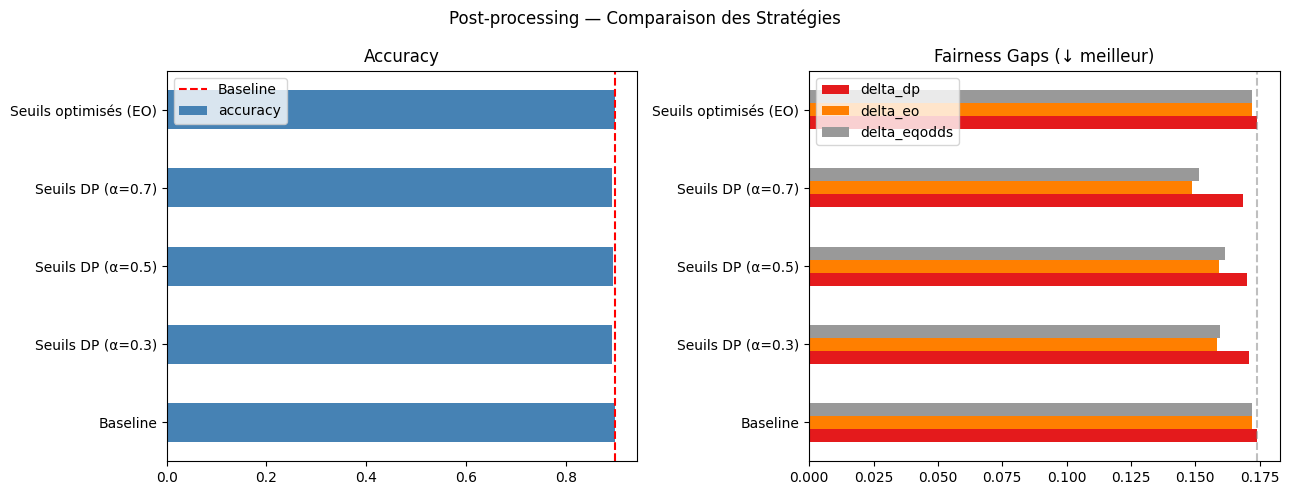


📊 TABLEAU RÉCAPITULATIF:
                       accuracy  delta_dp  delta_eo  delta_eqodds  mean_gap  accuracy_cost
Baseline                  0.899    0.1741    0.1720        0.1720    0.1727          0.000
Seuils DP (α=0.3)         0.892    0.1709    0.1584        0.1595    0.1629          0.007
Seuils DP (α=0.5)         0.894    0.1700    0.1593        0.1615    0.1636          0.005
Seuils DP (α=0.7)         0.893    0.1684    0.1487        0.1515    0.1562          0.006
Seuils optimisés (EO)     0.899    0.1741    0.1720        0.1720    0.1727          0.000

⚖️  Plus équitable: Seuils DP (α=0.7)
   Coût en accuracy: 0.0060
💾 postprocessing_results.csv
💾 optimal_thresholds_per_class.csv
💾 optimal_thresholds.json

🎉 Phase 4 terminée! → Phase 5: Évaluation & Synthèse


In [6]:
# Cellule 6: Comparaison finale + sauvegarde
compare_df = compare_and_plot(results,
    'Post-processing — Comparaison des Stratégies',
    'postprocessing_comparison.png')

compare_df['mean_gap'] = compare_df[['delta_dp','delta_eo','delta_eqodds']].mean(axis=1)
compare_df['accuracy_cost'] = fm_base['accuracy'] - compare_df['accuracy']

print('\n📊 TABLEAU RÉCAPITULATIF:')
print(compare_df[['accuracy','delta_dp','delta_eo','delta_eqodds','mean_gap','accuracy_cost']].round(4).to_string())

best = compare_df['mean_gap'].idxmin()
print(f'\n⚖️  Plus équitable: {best}')
print(f'   Coût en accuracy: {compare_df.loc[best, "accuracy_cost"]:.4f}')

# Tableau seuils optimaux
thresh_df = pd.DataFrame(optimal_thresholds).T

compare_df.to_csv(RESULTS / 'postprocessing_results.csv')
thresh_df.to_csv(RESULTS / 'optimal_thresholds_per_class.csv')

# Sauvegarder seuils pour Phase 5
import json
with open('../results/phase4/optimal_thresholds.json', 'w') as f:
    json.dump({k: {sk: float(sv) for sk, sv in v.items()} for k, v in optimal_thresholds.items()}, f, indent=2)

print('💾 postprocessing_results.csv')
print('💾 optimal_thresholds_per_class.csv')
print('💾 optimal_thresholds.json')
print('\n🎉 Phase 4 terminée! → Phase 5: Évaluation & Synthèse')
